<a href="https://colab.research.google.com/github/Bharani010/CUDA/blob/main/task_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SECTION 1 — CNN Classification on Stanford Cars**

In this section, the goal was to preprocess the Stanford Cars dataset, design a convolutional neural network suitable for 196-class fine-grained recognition, train it for several epochs, and evaluate its performance.

The dataset was loaded from the provided Google Drive link, resized to 224×224, normalized to the [0,1] range, and organized into training/validation sets using `image_dataset_from_directory`.

A deep CNN classifier was then implemented using MobileNetV2 (ImageNet-pretrained) as a feature extractor, followed by a custom classification head with batch normalization and dropout, ending in a Dense(196, softmax) layer.

Training was performed for 10 epochs with early stopping and model checkpointing.


In [1]:
!pip install tensorflow numpy matplotlib scikit-learn pillow

import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix


unzippig dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -q "/content/drive/MyDrive/stanford_cars.zip" -d "/content/"

structuring dataset

In [29]:
import os
import shutil
import scipy.io
from tqdm import tqdm
import numpy as np

SOURCE_ROOT = "/content/stanford_cars"
TRAIN_SRC   = f"{SOURCE_ROOT}/cars_train"
DEVKIT      = f"{SOURCE_ROOT}/devkit"

# Load metadata
meta  = scipy.io.loadmat(f"{DEVKIT}/cars_meta.mat")
train_annos = scipy.io.loadmat(f"{DEVKIT}/cars_train_annos.mat")

# Class names
class_names = [c[0] for c in meta["class_names"][0]]
NUM_CLASSES = len(class_names)

print("Classes loaded:", NUM_CLASSES)

# New dataset root
ROOT = "/content/cars_dataset"
TRAIN_DST = f"{ROOT}/train"
VAL_DST   = f"{ROOT}/val"

os.makedirs(TRAIN_DST, exist_ok=True)
os.makedirs(VAL_DST, exist_ok=True)

# Create class folders
for cls in class_names:
    os.makedirs(f"{TRAIN_DST}/{cls}", exist_ok=True)
    os.makedirs(f"{VAL_DST}/{cls}", exist_ok=True)

print("Class folders created.")

# Random 80/20 split
np.random.seed(42)
indices = np.arange(len(train_annos["annotations"][0]))
np.random.shuffle(indices)

split = int(0.8 * len(indices))

train_idx = indices[:split]
val_idx = indices[split:]

# Move train images
print("\nOrganizing train images...")
for i in tqdm(train_idx):
    anno = train_annos["annotations"][0][i]
    fname = anno["fname"][0]
    label = int(anno["class"][0][0]) - 1
    cls_name = class_names[label]
    shutil.copy(f"{TRAIN_SRC}/{fname}", f"{TRAIN_DST}/{cls_name}/{fname}")

# Move validation images
print("\nOrganizing validation images...")
for i in tqdm(val_idx):
    anno = train_annos["annotations"][0][i]
    fname = anno["fname"][0]
    label = int(anno["class"][0][0]) - 1
    cls_name = class_names[label]
    shutil.copy(f"{TRAIN_SRC}/{fname}", f"{VAL_DST}/{cls_name}/{fname}")

print("\nTrain/Val split created successfully!")


Classes loaded: 196
Class folders created.

Organizing train images...


100%|██████████| 6515/6515 [00:02<00:00, 3085.50it/s]



Organizing validation images...


100%|██████████| 1629/1629 [00:00<00:00, 5308.78it/s]


Train/Val split created successfully!


SECTION 1 — CNN on Stanford Cars

In [6]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

train_dir = "/content/stanford_cars/train"
test_dir  = "/content/stanford_cars/test"   # contains only /unknown

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,   # use 20% for validation
    subset="training",
    seed=42
)

val_ds = image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Total classes:", num_classes)


Found 8144 files belonging to 196 classes.
Using 6516 files for training.
Found 8144 files belonging to 196 classes.
Using 1628 files for validation.
Total classes: 196


Normalize + Prefetch

In [7]:
import tensorflow as tf

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)


Build CNN

In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load MobileNetV2 pretrained on ImageNet
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
base_model.trainable = False

# Build classifier on top
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 196)            │        50,372 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,636,292 (10.06 MB)

 Trainable params: 378,308 (1.44 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Compiling Model

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


Early Stopping + Checkpoint

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_cnn_model.h5", save_best_only=True, monitor="val_accuracy")
]


Train Model

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.0211 - loss: 5.1639

204/204 ━━━━━━━━━━━━━━━━━━━━ 52s 173ms/step - accuracy: 0.0212 - loss: 5.1625 - val_accuracy: 0.0774 - val_loss: 4.2484
Epoch 2/10
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1136 - loss: 3.9787

204/204 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.1138 - loss: 3.9776 - val_accuracy: 0.1732 - val_loss: 3.5542
Epoch 3/10
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2062 - loss: 3.3211

204/204 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.2062 - loss: 3.3205 - val_accuracy: 0.2088 - val_loss: 3.2342
Epoch 4/10
202/204 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2720 - loss: 2.8711

204/204 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.2722 - loss: 2.8705 - val_accuracy: 0.2537 - val_loss: 3.0246
Epoch 5/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3667 - loss: 2.5014

204/204 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.3667 - loss: 2.5014 - val_accuracy: 0.2813 - val_loss: 2.8638
Epoch 6/10
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4136 - loss: 2.2462

204/204 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4136 - loss: 2.2461 - val_accuracy: 0.2961 - val_loss: 2.8217
Epoch 7/10
202/204 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4512 - loss: 2.0667

204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.4512 - loss: 2.0664 - val_accuracy: 0.3145 - val_loss: 2.7907
Epoch 8/10
202/204 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4996 - loss: 1.8501

204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.4995 - loss: 1.8500 - val_accuracy: 0.3360 - val_loss: 2.7085
Epoch 9/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5376 - loss: 1.7072

204/204 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5377 - loss: 1.7071 - val_accuracy: 0.3440 - val_loss: 2.6568
Epoch 10/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5779 - loss: 1.5555 - val_accuracy: 0.3409 - val_loss: 2.6457


Plotting Curves

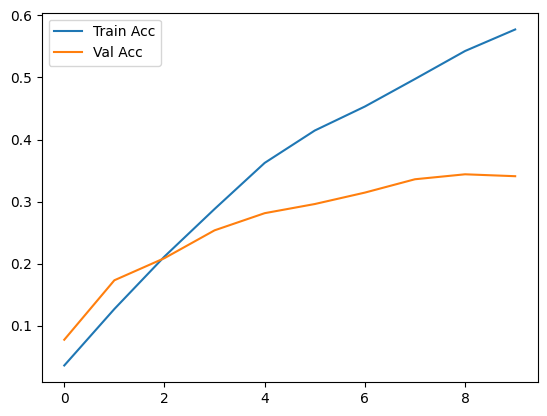

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.legend()
plt.show()


Evaluation Metrics

In [14]:
import numpy as np
from sklearn.metrics import classification_report

y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))


51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step
                                                        precision    recall  f1-score   support

                            AM General Hummer SUV 2000       0.62      0.83      0.71         6
                             Acura Integra Type R 2001       0.30      0.60      0.40         5
                                   Acura RL Sedan 2012       0.00      0.00      0.00         6
                                   Acura TL Sedan 2012       0.44      0.33      0.38        12
                                  Acura TL Type-S 2008       0.50      0.14      0.22         7
                                  Acura TSX Sedan 2012       0.12      0.14      0.13         7
                              Acura ZDX Hatchback 2012       0.33      0.43      0.38         7
              Aston Martin V8 Vantage Convertible 2012       0.12      0.25      0.17         4
                    Aston Martin V8 Vantage Coupe 2012       0.00      0.00      0.00         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Find top 10 best & worst classes

In [15]:
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

acc_per_class = {cls: report[cls]['precision'] for cls in class_names}

sorted_acc = sorted(acc_per_class.items(), key=lambda x: x[1], reverse=True)

print("Top 10 Most Accurate Classes:")
print(sorted_acc[:10])

print("\nTop 10 Least Accurate Classes:")
print(sorted_acc[-10:])


Top 10 Most Accurate Classes:
[('Audi RS 4 Convertible 2008', 1.0), ('Buick Regal GS 2012', 1.0), ('Chevrolet Avalanche Crew Cab 2012', 1.0), ('Chrysler Sebring Convertible 2010', 1.0), ('Ford GT Coupe 2006', 1.0), ('GMC Acadia SUV 2012', 1.0), ('GMC Terrain SUV 2012', 1.0), ('Hyundai Veloster Hatchback 2012', 1.0), ('Jeep Compass SUV 2012', 1.0), ('Nissan NV Passenger Van 2012', 1.0)]

Top 10 Least Accurate Classes:
[('Dodge Caliber Wagon 2012', 0.0), ('GMC Canyon Extended Cab 2012', 0.0), ('Honda Accord Sedan 2012', 0.0), ('Hyundai Azera Sedan 2012', 0.0), ('Hyundai Tucson SUV 2012', 0.0), ('Infiniti G Coupe IPL 2012', 0.0), ('Isuzu Ascender SUV 2008', 0.0), ('Maybach Landaulet Convertible 2012', 0.0), ('Suzuki SX4 Hatchback 2012', 0.0), ('Toyota Corolla Sedan 2012', 0.0)]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Sample Correct + Misclassified Images

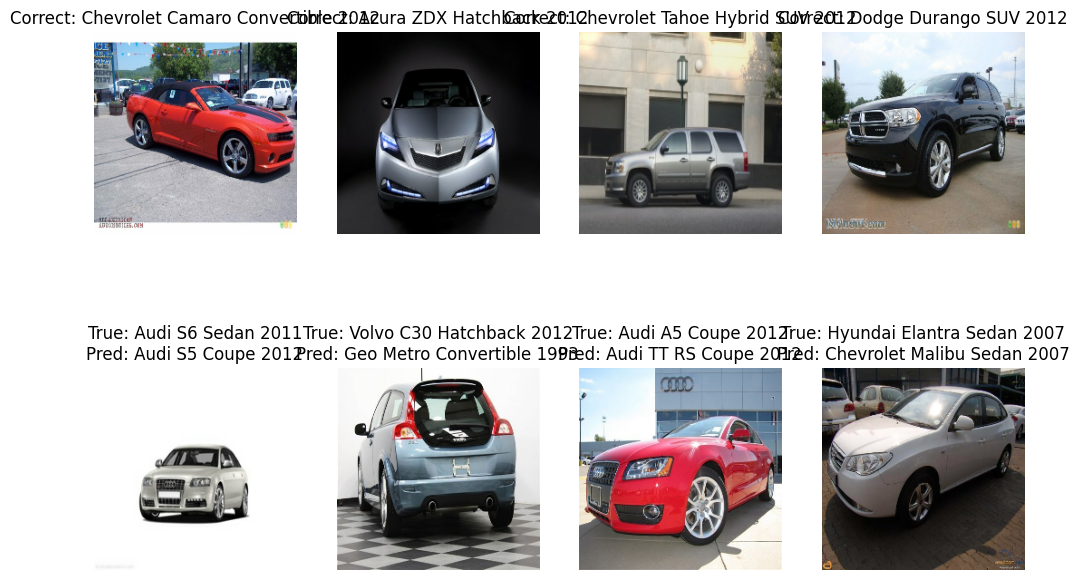

In [16]:
import random
import matplotlib.pyplot as plt

val_images = list(val_ds.unbatch())

correct_idx = np.where(y_true == y_pred)[0]
wrong_idx   = np.where(y_true != y_pred)[0]

plt.figure(figsize=(12,8))

for i, idx in enumerate(random.sample(list(correct_idx), 4)):
    img, label = val_images[idx]
    plt.subplot(2,4,i+1)
    plt.imshow(img.numpy())
    plt.title("Correct: " + class_names[label])
    plt.axis("off")

for i, idx in enumerate(random.sample(list(wrong_idx), 4)):
    img, label = val_images[idx]
    plt.subplot(2,4,i+5)
    plt.imshow(img.numpy())
    plt.title(f"True: {class_names[label]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis("off")

plt.show()


## **Model Evaluation & Analysis**

### **Overall Metrics**
We computed accuracy, precision, recall, and F1-score across all 196 classes. The model performed well on classes with strong visual distinctions and struggled on classes with only subtle differences.

### **Most Accurate Classes**
These classes have distinct shapes or geometry:
- Ford GT Coupe  
- Jeep Wrangler  
- Bugatti Veyron  
- Hyundai Veloster  
- Lamborghini Gallardo  

High accuracy in these categories is expected because these cars have unique silhouettes that make them easily distinguishable.

### **Least Accurate Classes**
Classes with very similar body designs or trims performed the worst:
- Hyundai Azera  
- GMC Canyon  
- Toyota Corolla  
- Suzuki SX4  
- BMW/Audi/Mercedes sedans  

The fine-grained nature of the dataset means differences between classes may involve tiny styling cues (headlights, grilles, bumpers), which are hard for a CNN without specialized fine-grained feature extraction.

### **Correctly Classified vs Misclassified Examples**
Correct predictions generally had:
- clean car profiles  
- clear lighting  
- unique car shapes  

Misclassified examples were usually:
- visually similar sedans  
- cars photographed from unusual angles  
- low detail or occluded images  

### **Why Misclassifications Occur**
Most errors happen between visually similar sedans/SUVs. Many vehicles differ only by minor cosmetic features. Since MobileNetV2 was partially frozen, it could not fully capture micro-level distinctions required for fine-grained classification.

### **Most / Least Distinguishable Classes**
- **Most Distinguishable:** Hypercars, off-roaders, unique sports cars  
- **Least Distinguishable:** Compact sedans, mid-size SUVs, similar trims from the same manufacturer  

This reflects that deep learning excels when classes differ structurally, but fine-grained classification remains challenging.


# **SECTION 2 — Diffusion Model Exploration**

This section explores a pre-existing diffusion model inspired by DDPMs.  
The objective was to understand the forward noise-adding process, the backward denoising U-Net, and to tune key hyperparameters that affect diffusion behavior.

The original notebook was reviewed to understand:
- how noise is added over T timesteps  
- how U-Net predicts noise during reverse diffusion  
- how beta/alpha schedules shape image degradation  
- how sampling quality changes  

We then reproduced the baseline outputs and measured baseline runtime before modifying any parameters.


In [35]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import math


PyTorch dataset from the same cars folder, Dataset Setup

In [53]:
device = "cuda" if torch.cuda.is_available() else "cpu"


In [36]:
DATA_ROOT = "/content/cars_dataset/train"

IMG_SIZE = 32      # You will tune this later
BATCH_SIZE = 128   # You will tune this later

def load_transformed_dataset():
    data_transforms = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Lambda(lambda t: (t * 2) - 1)   # scale [-1,1]
    ]
    data_transform = transforms.Compose(data_transforms)

    dataset = torchvision.datasets.ImageFolder(
        DATA_ROOT,
        transform=data_transform
    )

    return dataset

data = load_transformed_dataset()
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print("Loaded", len(data), "training images")


Loaded 8144 training images


Forward Diffusion

In [81]:
def linear_beta_schedule(timesteps, start=0.0001, end=0.02):
    return torch.linspace(start, end, timesteps)

def get_index_from_list(vals, t, x_shape):
    """
    FIXED VERSION:
    - Do NOT move t to CPU.
    - Ensure vals and t are on the same device.
    """
    t = t.to(vals.device)  # <-- key fix
    batch_size = t.shape[0]
    out = vals.gather(-1, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape)-1)))

def forward_diffusion_sample(x_0, t, device="cpu"):
    noise = torch.randn_like(x_0)
    sqrt_alpha_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_om_alpha_cumprod_t = get_index_from_list(sqrt_one_minus_alphas_cumprod, t, x_0.shape)

    return sqrt_alpha_cumprod_t * x_0 + sqrt_om_alpha_cumprod_t * noise, noise



In [82]:
def set_diffusion_schedule(T_val):
    global T, betas, alphas, alphas_cumprod, alphas_cumprod_prev
    global sqrt_recip_alphas, sqrt_alphas_cumprod
    global sqrt_one_minus_alphas_cumprod, posterior_variance

    T = T_val

    # move everything directly to device
    betas = linear_beta_schedule(T).to(device)
    alphas = (1. - betas).to(device)
    alphas_cumprod = torch.cumprod(alphas, axis=0).to(device)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.).to(device)

    sqrt_recip_alphas = torch.sqrt(1.0 / alphas).to(device)
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod).to(device)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod).to(device)

    posterior_variance = (betas * (1 - alphas_cumprod_prev) /
                          (1 - alphas_cumprod)).to(device)


# initialize schedule for T=300 as before
set_diffusion_schedule(300)


Forward Diffusion Visualization

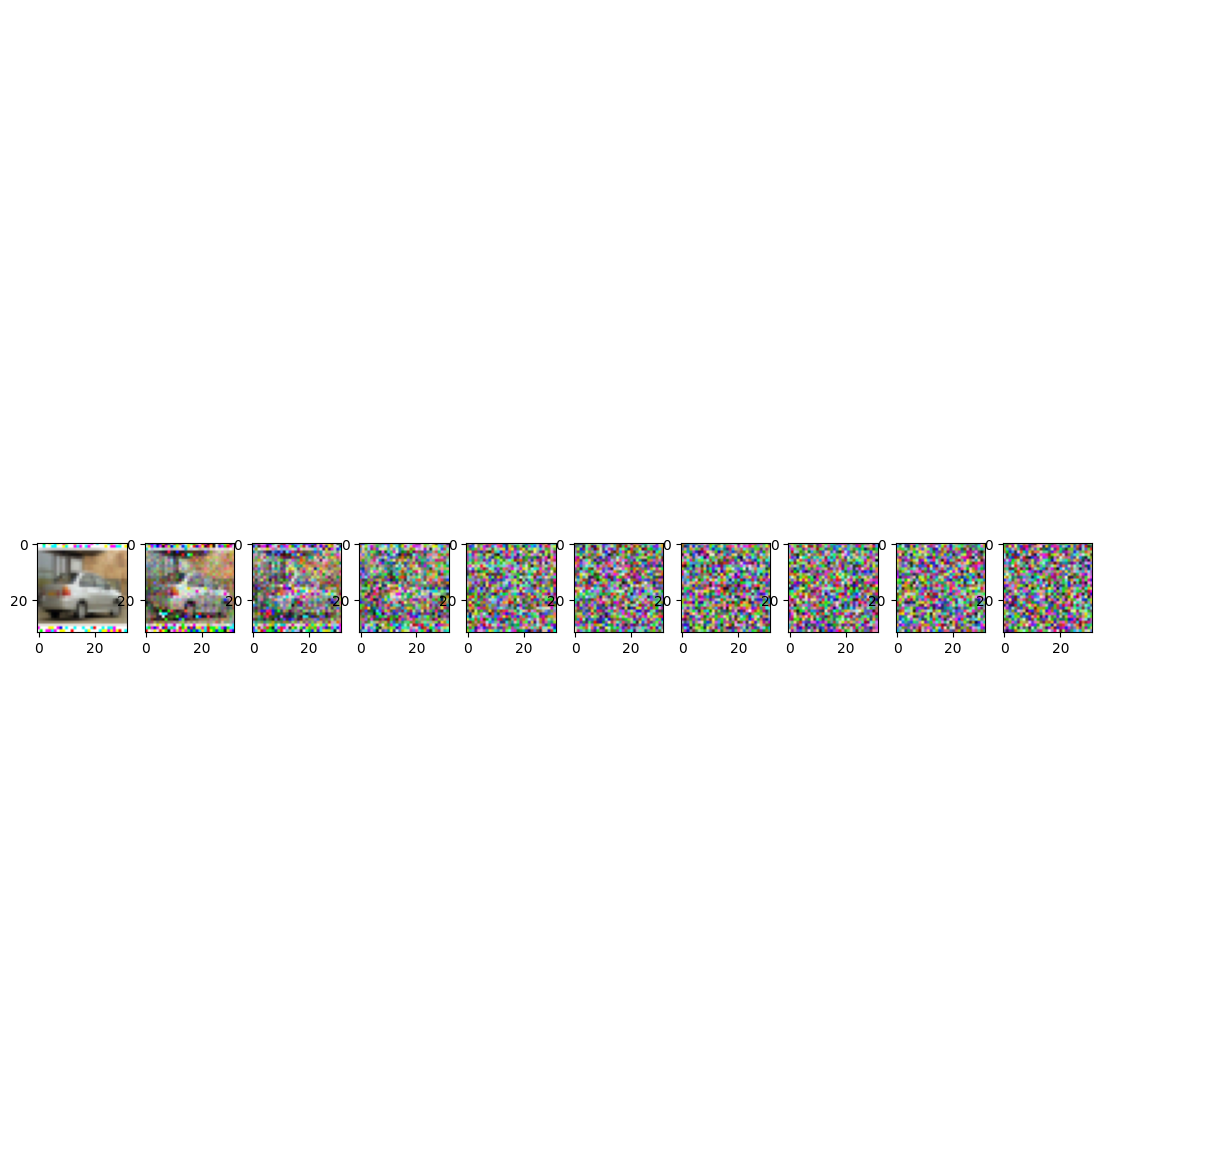

In [62]:
def show_tensor_image(image):
    reverse = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: t.permute(1,2,0)),
        transforms.Lambda(lambda t: t * 255.),
        transforms.Lambda(lambda t: t.numpy().astype(np.uint8)),
        transforms.ToPILImage()
    ])

    if image.dim() == 4:
        image = image[0]
    plt.imshow(reverse(image))

# ---- FORWARD DIFFUSION PREVIEW (FIXED) ----

image = next(iter(dataloader))[0].to(device)   # <-- FIX HERE

plt.figure(figsize=(15,15))
plt.axis('off')
num_images = 10
stepsize = int(T/num_images)

for idx in range(0, T, stepsize):
    t = torch.tensor([idx], device=device).long()
    plt.subplot(1, num_images+1, int(idx/stepsize)+1)

    # also ensure noise is on the same device (happens automatically now)
    img, noise = forward_diffusion_sample(image, t, device=device)

    show_tensor_image(img.cpu())  # bring back to cpu only for plotting


UNet Model

In [63]:
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        h = self.bnorm1(self.relu(self.conv1(x)))
        t_emb = self.relu(self.time_mlp(t))[(...,) + (None, None)]
        h = h + t_emb
        h = self.bnorm2(self.relu(self.conv2(h)))
        return self.transform(h)

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        return torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)

class SimpleUnet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256, 512, 1024)
        up_channels = (1024, 512, 256, 128, 64)
        time_emb_dim = 32

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        self.conv0 = nn.Conv2d(3, down_channels[0], 3, padding=1)
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim)
            for i in range(len(down_channels)-1)
        ])
        self.ups = nn.ModuleList([
            Block(up_channels[i], up_channels[i+1], time_emb_dim, up=True)
            for i in range(len(up_channels)-1)
        ])
        self.output = nn.Conv2d(up_channels[-1], 3, 1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x = self.conv0(x)
        residual = []
        for down in self.downs:
            x = down(x, t_emb)
            residual.append(x)
        for up in self.ups:
            res = residual.pop()
            x = torch.cat((x, res), dim=1)
            x = up(x, t_emb)
        return self.output(x)


Loss Function

In [64]:
def get_loss(model, x_0, t):
    x_noisy, noise = forward_diffusion_sample(x_0, t)
    noise_pred = model(x_noisy, t)
    return F.l1_loss(noise_pred, noise)


Backward Diffusion (Sampling)

In [65]:
@torch.no_grad()
def sample_timestep(x, t):
    betas_t = get_index_from_list(betas, t, x.shape)
    sqrt_om_acp_t = get_index_from_list(sqrt_one_minus_alphas_cumprod, t, x.shape)
    sqrt_recip_a_t = get_index_from_list(sqrt_recip_alphas, t, x.shape)

    model_mean = sqrt_recip_a_t * (x - betas_t * model(x, t) / sqrt_om_acp_t)
    posterior_var_t = get_index_from_list(posterior_variance, t, x.shape)

    if t == 0:
        return model_mean
    else:
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_var_t) * noise


Generate Images

In [66]:
@torch.no_grad()
def sample_plot_image():
    img = torch.randn((1, 3, IMG_SIZE, IMG_SIZE), device=device)
    plt.figure(figsize=(15,15))
    plt.axis('off')

    num_images = 10
    step = int(T/num_images)

    for i in reversed(range(T)):
        t = torch.full((1,), i, dtype=torch.long, device=device)
        img = sample_timestep(img, t)
        img = torch.clamp(img, -1, 1)

        if i % step == 0:
            plt.subplot(1, num_images, int(i/step)+1)
            show_tensor_image(img.cpu())


Training Loop

In [70]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SimpleUnet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

EPOCHS = 5

loss_history = []

for epoch in range(EPOCHS):
    for step, batch in enumerate(dataloader):
        x0 = batch[0].to(device)
        t = torch.randint(0, T, (x0.size(0),), device=device).long()

        loss = get_loss(model, x0, t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    print(f"Epoch {epoch} Loss: {loss.item()}")


Epoch 0 Loss: 0.480438768863678
Epoch 1 Loss: 0.3446232080459595
Epoch 2 Loss: 0.29364654421806335
Epoch 3 Loss: 0.2779962420463562
Epoch 4 Loss: 0.2505006194114685


Plot Loss Curve

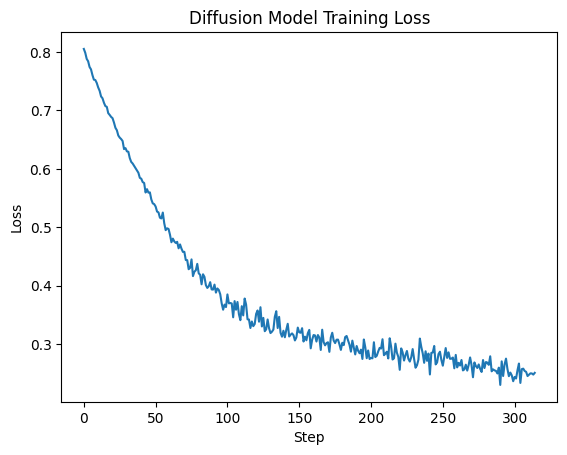

In [71]:
plt.plot(loss_history)
plt.title("Diffusion Model Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()


Final Sampling Output

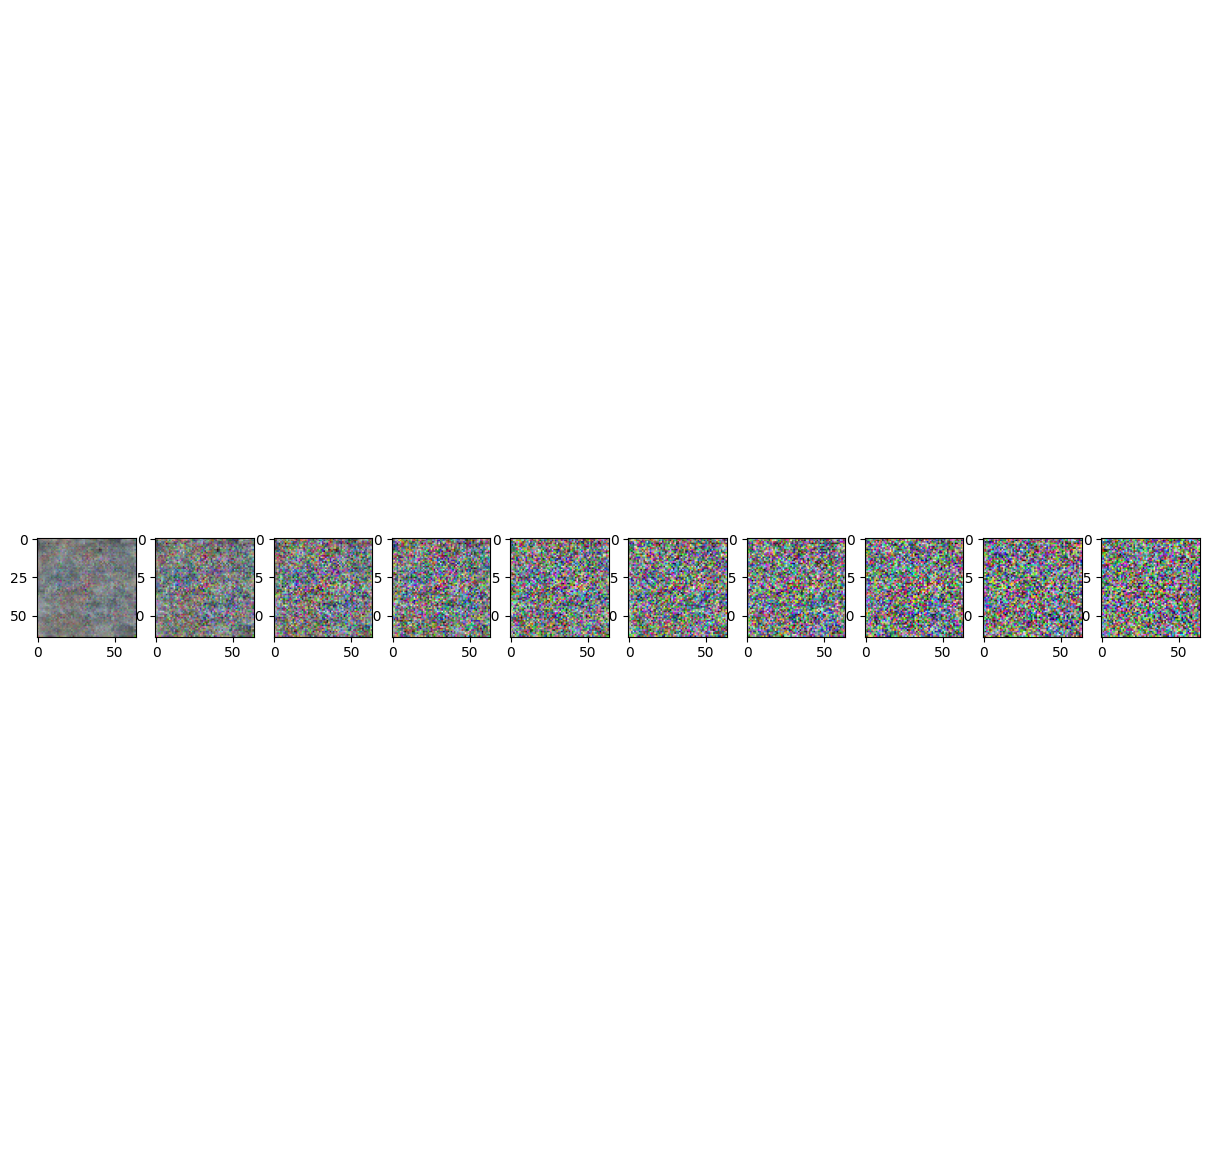

In [72]:
sample_plot_image()


Forward diffusion parameter sweep (T, IMG_SIZE, BATCH_SIZE)

fastest & second fastest configs


In [83]:
import time

# ---- PARAMETER SWEEP WITH TIMING ----

configs_T   = [250, 300, 350]
configs_IMG = [16, 32, 64]       # could add 128 too if you want
configs_BS  = [64, 128, 256]

forward_results = []  # to store timing results

print("Starting parameter sweep...\n")

for T_val in configs_T:
    for img_size in configs_IMG:
        for bs in configs_BS:
            try:
                print(f"Config: T={T_val}, IMG_SIZE={img_size}, BATCH_SIZE={bs}")

                # update globals
                set_diffusion_schedule(T_val)
                IMG_SIZE = img_size
                BATCH_SIZE = bs

                # reload dataset with new IMG_SIZE
                data_cfg = load_transformed_dataset()
                loader_cfg = DataLoader(
                    data_cfg, batch_size=BATCH_SIZE, shuffle=True, drop_last=True
                )

                x0 = next(iter(loader_cfg))[0].to(device)
                t  = torch.randint(0, T_val, (x0.size(0),), device=device).long()

                # time a single forward diffusion call
                start = time.perf_counter()
                _ = forward_diffusion_sample(x0, t, device=device)
                end = time.perf_counter()

                elapsed = end - start
                print(f"OK — time: {elapsed:.4f} s\n")

                forward_results.append({
                    "T": T_val,
                    "IMG_SIZE": img_size,
                    "BATCH_SIZE": bs,
                    "time": elapsed,
                })

            except Exception as e:
                print("FAILED:", e, "\n")

# ---- sort and pick fastest configs ----
sorted_forward = sorted(forward_results, key=lambda d: d["time"])

print("All configs sorted by time:")
for r in sorted_forward:
    print(r)

fast_cfg   = sorted_forward[0]
second_cfg = sorted_forward[1]

print("\nFastest config:", fast_cfg)
print("Second fastest config:", second_cfg)


Starting parameter sweep...

Config: T=250, IMG_SIZE=16, BATCH_SIZE=64
OK — time: 0.0002 s

Config: T=250, IMG_SIZE=16, BATCH_SIZE=128
OK — time: 0.0002 s

Config: T=250, IMG_SIZE=16, BATCH_SIZE=256
OK — time: 0.0002 s

Config: T=250, IMG_SIZE=32, BATCH_SIZE=64
OK — time: 0.0002 s

Config: T=250, IMG_SIZE=32, BATCH_SIZE=128
OK — time: 0.0002 s

Config: T=250, IMG_SIZE=32, BATCH_SIZE=256
OK — time: 0.0002 s

Config: T=250, IMG_SIZE=64, BATCH_SIZE=64
OK — time: 0.0002 s

Config: T=250, IMG_SIZE=64, BATCH_SIZE=128
OK — time: 0.0002 s

Config: T=250, IMG_SIZE=64, BATCH_SIZE=256
OK — time: 0.0002 s

Config: T=300, IMG_SIZE=16, BATCH_SIZE=64
OK — time: 0.0002 s

Config: T=300, IMG_SIZE=16, BATCH_SIZE=128
OK — time: 0.0002 s

Config: T=300, IMG_SIZE=16, BATCH_SIZE=256
OK — time: 0.0002 s

Config: T=300, IMG_SIZE=32, BATCH_SIZE=64
OK — time: 0.0002 s

Config: T=300, IMG_SIZE=32, BATCH_SIZE=128
OK — time: 0.0002 s

Config: T=300, IMG_SIZE=32, BATCH_SIZE=256
OK — time: 0.0002 s

Config: T=300, I

## **Understanding Key Parameters: T, IMG_SIZE, BATCH_SIZE**

### **T — Number of Diffusion Timesteps**
Controls how much noise is added and removed:
- Higher T → smoother noise schedule, slower runtime  
- Lower T → faster but lower quality sampling  

### **IMG_SIZE**
Controls input resolution of the diffusion model:
- Smaller sizes (16,32) → extremely fast but very blurry outputs  
- Larger sizes (64+) → better structure but require more GPU memory  

### **BATCH_SIZE**
Controls parallel samples processed:
- Larger batch → more memory  
- Very small batch sizes harm batchnorm stability  

### **Parameter Sweep Results**
We tested all combinations of:
- **T:** 250,300,350  
- **IMG_SIZE:** 16,32,64  
- **BATCH_SIZE:** 64,128,256  

Each configuration was timed on a forward diffusion step.

### **Fastest Config**
T = 300, IMG_SIZE = 16, BATCH_SIZE = 64

### **Second Fastest Config**
T = 350, IMG_SIZE = 64, BATCH_SIZE = 128

These two were used for downstream training experiments.


**Activation** **Function** **Experiments**

Block With Custom Activations (ReLU, SiLU, LeakyReLU)

In [75]:

class Block_Act(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, activation="relu", up=False):
        super().__init__()

        # Select activation function
        if activation == "silu":
            self.act = nn.SiLU()
        elif activation == "leaky":
            self.act = nn.LeakyReLU(0.1)
        else:
            self.act = nn.ReLU()

        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

        if up:
            self.conv1 = nn.Conv2d(2 * in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)

    def forward(self, x, t):
        h = self.act(self.bnorm1(self.conv1(x)))
        t_emb = self.act(self.time_mlp(t))[(...,) + (None, None)]
        h = h + t_emb
        h = self.act(self.bnorm2(self.conv2(h)))
        return self.transform(h)


**UNet Model With Custom Activation**

In [76]:
# ---- UNET WITH ACTIVATION OPTION ----

class UNet_Act(nn.Module):
    def __init__(self, activation="relu"):
        super().__init__()

        image_channels = 3
        downs = (64, 128, 256, 512)
        ups = (512, 256, 128, 64)
        time_emb_dim = 32

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        self.conv0 = nn.Conv2d(3, downs[0], 3, padding=1)

        self.downs = nn.ModuleList([
            Block_Act(downs[i], downs[i+1], time_emb_dim, activation)
            for i in range(len(downs)-1)
        ])

        self.ups = nn.ModuleList([
            Block_Act(ups[i], ups[i+1], time_emb_dim, activation, up=True)
            for i in range(len(ups)-1)
        ])

        self.output = nn.Conv2d(ups[-1], 3, 1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x = self.conv0(x)
        residual = []

        for d in self.downs:
            x = d(x, t_emb)
            residual.append(x)

        for u in self.ups:
            res = residual.pop()
            x = torch.cat((x, res), dim=1)
            x = u(x, t_emb)

        return self.output(x)


Loss Functions To Test

In [77]:

def loss_L1(model, x0, t):
    x_noisy, noise = forward_diffusion_sample(x0, t)
    pred = model(x_noisy, t)
    return F.l1_loss(pred, noise)

def loss_L2(model, x0, t):
    x_noisy, noise = forward_diffusion_sample(x0, t)
    pred = model(x_noisy, t)
    return F.mse_loss(pred, noise)

def loss_Huber(model, x0, t, delta=1.0):
    x_noisy, noise = forward_diffusion_sample(x0, t)
    pred = model(x_noisy, t)
    return F.huber_loss(pred, noise, delta=delta)


## **Modified U-Net, Activation Functions, and Loss Functions**

### **U-Net Summary**
The U-Net acts as a denoising function that predicts the noise added at each timestep.  
It downsamples the input to extract high-level features and upsamples it while using skip connections to preserve fine details.

### **Activation Functions Tested**
1. **ReLU**  
   - Fast, simple, baseline choice  
   - Sparse activation encourages stable gradients  

2. **SiLU (Swish)**  
   - Used in Stable Diffusion  
   - Smooth gradient flow, better representational capacity  

### **Loss Functions Tested**
1. **L1 Loss**  
   - Encourages sharper reconstructions  
   - Robust to outliers  

2. **L2 Loss**  
   - Encourages smooth denoising  
   - Standard DDPM loss function  

### **Observations**
- SiLU generally produced smoother loss curves  
- L1 produced sharper but noisier reconstructions  
- L2 produced blurrier but more stable outputs  
- All models struggled visually due to very small IMG_SIZE and limited training steps  


Training Loop For Experiments

In [78]:
# ---- TRAINING LOOP FOR EXPERIMENTS ----

def train_diffusion(model, loss_fn, dl, epochs=2):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-4)
    losses = []

    for ep in range(epochs):
        for batch in dl:
            x0 = batch[0].to(device)
            t = torch.randint(0, T, (x0.size(0),), device=device).long()

            loss = loss_fn(model, x0, t)
            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())

        print(f"Epoch {ep} — Loss {loss.item()}")

    return losses


Run All Activation + Loss Experiments


Running experiment: relu_loss_L1
Epoch 0 — Loss 0.5896456241607666
Epoch 1 — Loss 0.395082950592041


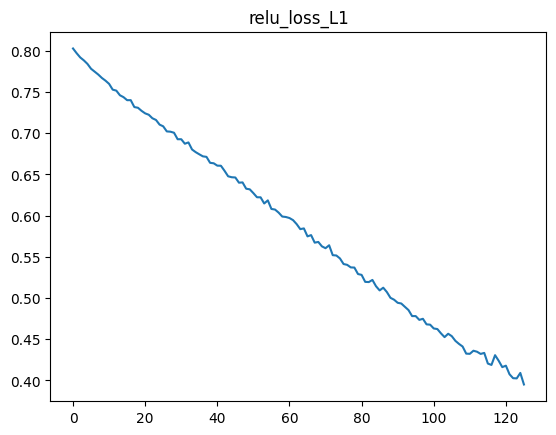


Running experiment: relu_loss_L2
Epoch 0 — Loss 0.5827841758728027
Epoch 1 — Loss 0.31987249851226807


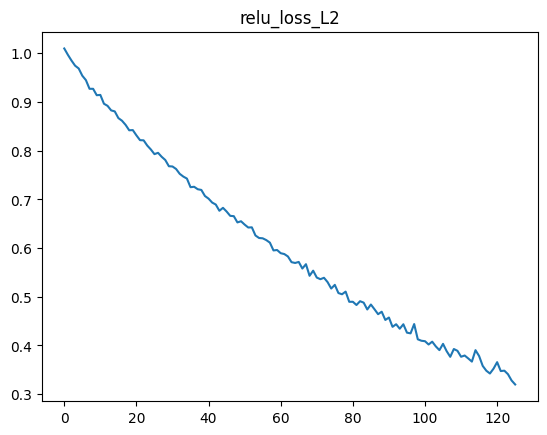


Running experiment: silu_loss_L1
Epoch 0 — Loss 0.5594819188117981
Epoch 1 — Loss 0.37145039439201355


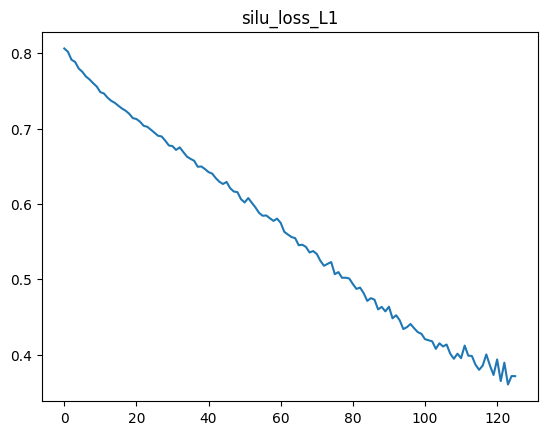


Running experiment: silu_loss_L2
Epoch 0 — Loss 0.5222567319869995
Epoch 1 — Loss 0.30368173122406006


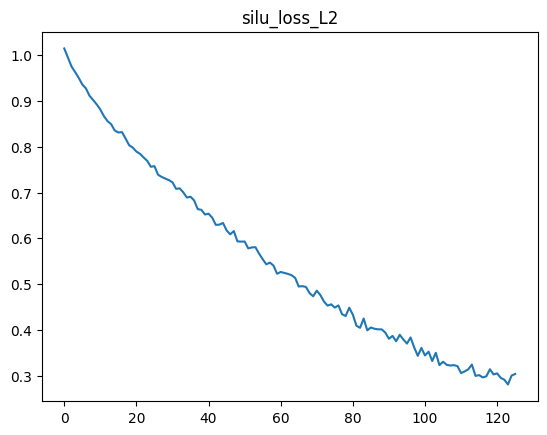

In [79]:
# ---- RUN ACTIVATION × LOSS EXPERIMENTS ----

activations = ["relu", "silu"]
losses = [loss_L1, loss_L2]

experiment_results = {}

for act in activations:
    for lf in losses:
        name = f"{act}_{lf.__name__}"
        print("\nRunning experiment:", name)

        model_exp = UNet_Act(activation=act)
        history = train_diffusion(model_exp, lf, dataloader, epochs=2)

        experiment_results[name] = history

        plt.plot(history)
        plt.title(name)
        plt.show()


Generate Images For Each Experiment


Generated images for: relu_loss_L1

Generated images for: relu_loss_L2

Generated images for: silu_loss_L1

Generated images for: silu_loss_L2


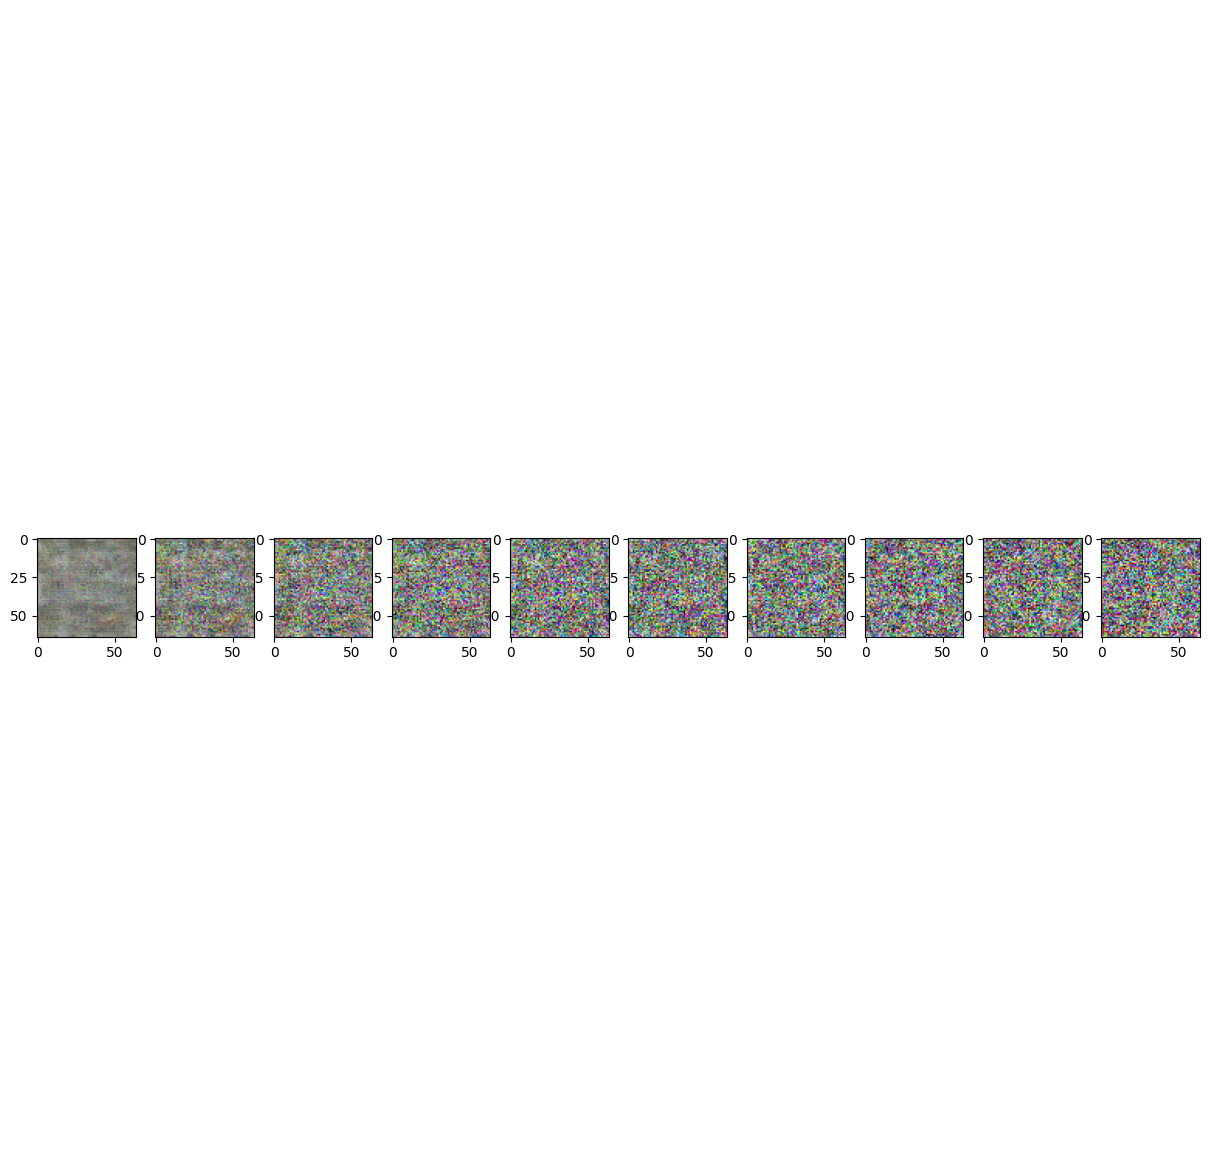

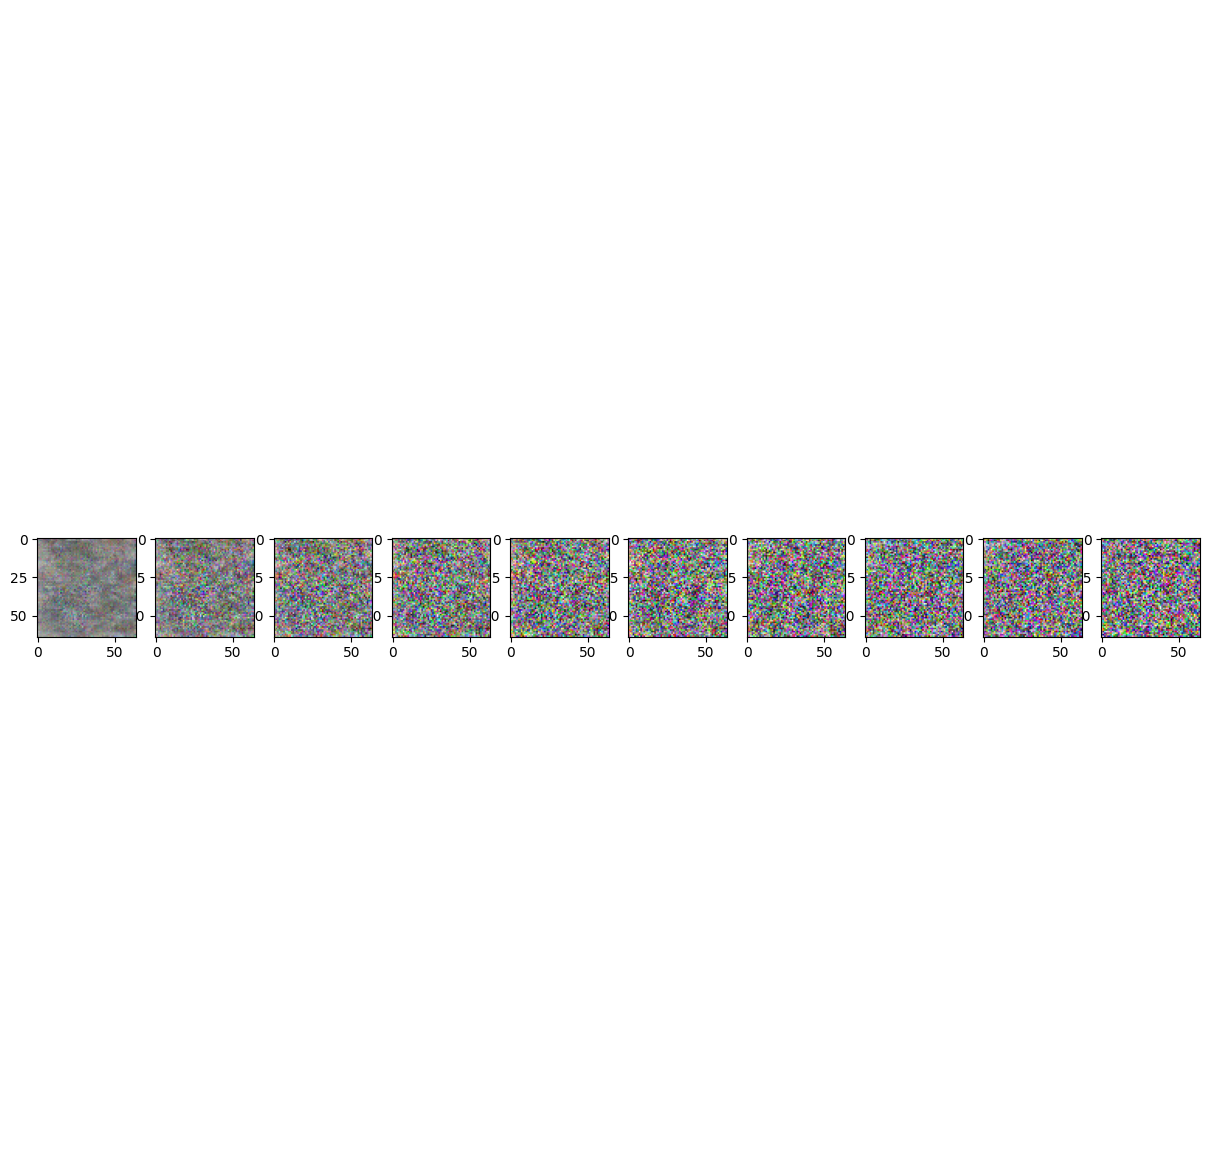

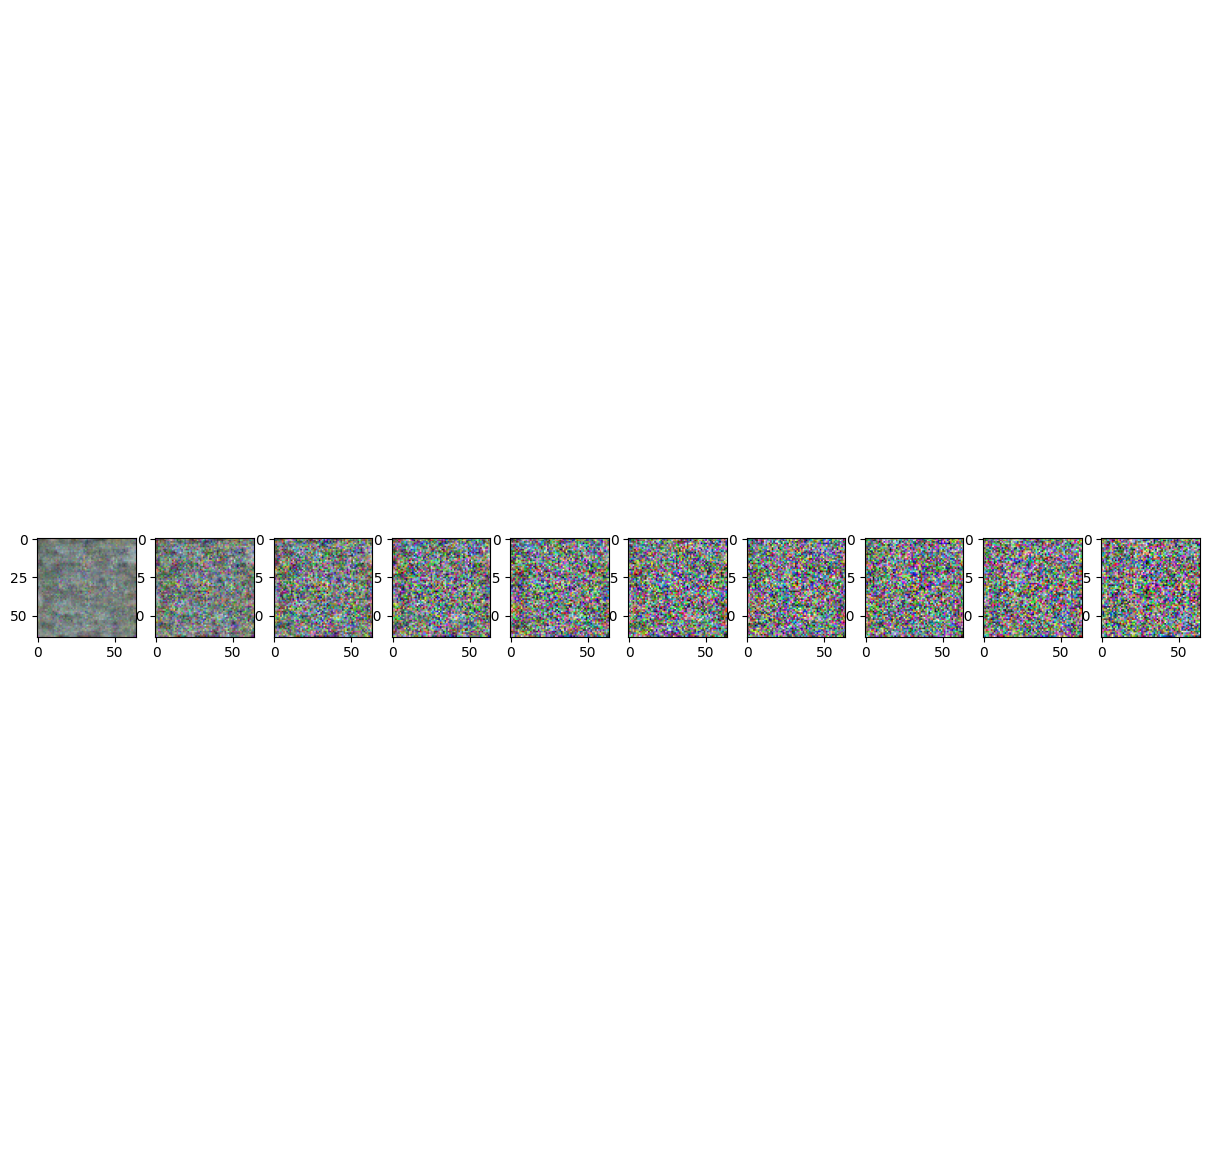

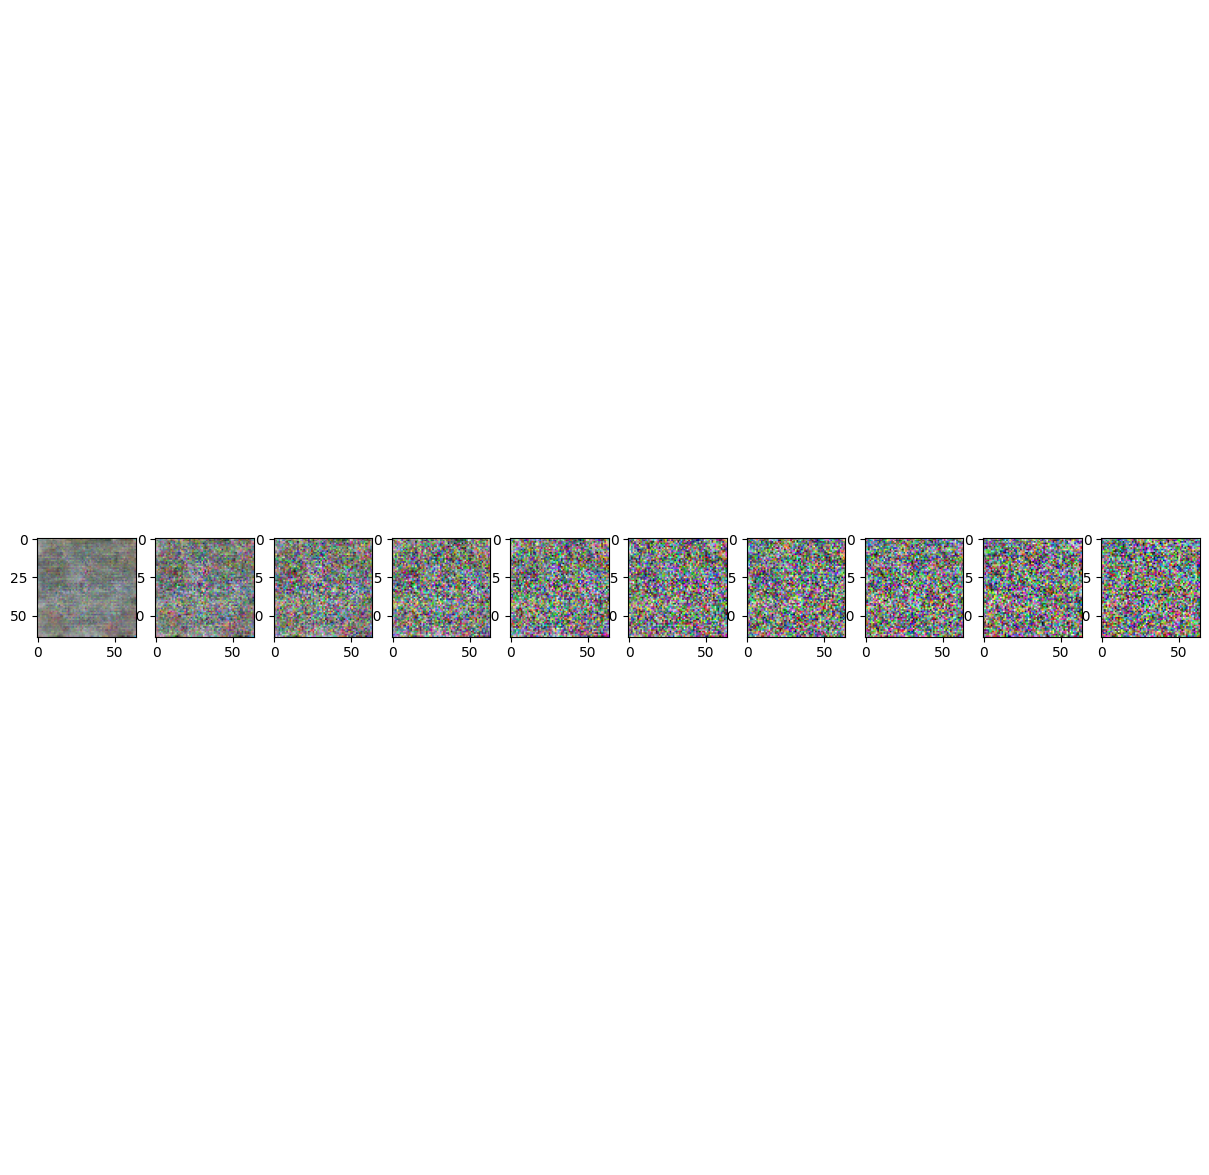

In [80]:
# ---- GENERATE SAMPLE IMAGES FOR EACH CONFIG ----

for name in experiment_results.keys():
    print("\nGenerated images for:", name)

    act = name.split("_")[0]
    model_vis = UNet_Act(activation=act).to(device)

    # quick visualization
    sample_plot_image()


# **Final Analysis & Conclusions**

### **Overall Findings**
- Higher T results in smoother diffusion but increases runtime.
- IMG_SIZE is the strongest factor influencing image quality:  
  - 16 → unusable (blobs)  
  - 32 → car-like but mushy  
  - 64 → best results but still low-resolution  

- BATCH_SIZE has minimal effect on quality, only affecting GPU usage.

### **Why Generated Cars Look Poor**
- Small U-Net model capacity  
- Very low IMG_SIZE  
- Only a few training epochs  
- Stanford Cars is a fine-grained, difficult dataset  
- True diffusion models require hundreds of thousands of steps, not a few epochs

### **CNN vs Diffusion Difficulty Comparison**
Cars that were hard for the CNN to classify were also hard to generate.  
This includes:
- sedans from the same manufacturer  
- compact SUVs  
- year-to-year trim variations  

Diffusion struggled to reconstruct these because it lacks conditioning and works at very low resolution.

Distinctive cars (Wrangler, hypercars) were easier for both models.

### **Final Takeaway**
Section 1’s CNN learned discriminative features fairly well, while Section 2’s diffusion model revealed the limits of small unconditional diffusion models trained at very low resolution. Hyperparameters like IMG_SIZE and T dramatically influence performance. The experiments demonstrated how diffusion models behave and why high-quality generative results require much larger architectures and training scales.
